# SEMAI Forecast: will the greenhouse need misting in the next 2 hours?

**Team:** Brand New Developers · **Programme:** PSC GET Talent 2026 · **SDG 9:** Industry, Innovation and Infrastructure

**Problem.** Plants lose water according to **VPD** (vapour-pressure deficit, in kPa), not humidity alone. Our greenhouse rig mists when VPD rises above **1.2 kPa**. A controller only reacts once the air is already dry. We want to warn **two hours ahead**, so a small grower can get ready before Penang's hot afternoons.

**Task.** This is supervised **classification**. For every hour *t*, the question is: will VPD be above 1.2 kPa at hour *t+1* or *t+2*? (1 = misting needed soon, 0 = not.)

**Data.** Three years of hourly Penang weather (2023–2025) from the Open-Meteo Historical Weather API (ERA5 reanalysis). That is 26,304 rows and 25 weather columns.

The notebook runs top to bottom in about a minute: `Kernel → Restart & Run All`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
import joblib

RAW   = Path("dataset/penang_weather_hourly_2023_2025_raw.csv")
CLEAN = Path("dataset/penang_weather_hourly_2023_2025_clean.csv")
FIG   = Path("figures"); FIG.mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)
MIST_KPA = 1.2          # the rig's misting threshold
SEED = 0
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Load the raw dataset

This is the file exactly as the Open-Meteo website exports it:
- 3 metadata lines at the top (location, elevation, time zone)
- units written inside the column names
- some duplicated columns

Cleaning it is the next step.

In [2]:
meta = pd.read_csv(RAW, nrows=1)
raw = pd.read_csv(RAW, skiprows=3)
print("Location:", meta.to_dict("records")[0])
print("Raw shape:", raw.shape, "(rows, columns)")
raw.head()

Location: {'latitude': 5.448155, 'longitude': 100.28998, 'elevation': 157.0, 'utc_offset_seconds': 28800, 'timezone': 'Asia/Kuala_Lumpur', 'timezone_abbreviation': 'GMT+8'}
Raw shape: (26304, 26) (rows, columns)


,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),...,wind_direction_10m (°),wind_gusts_10m (km/h),surface_pressure (hPa),pressure_msl (hPa),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),soil_temperature_0_to_7cm (°C),soil_moisture_0_to_7cm (m³/m³),is_day (),weather_code (wmo code)
0,2023-01-01T00:00,25.1,79,21.3,28.0,0.0,0.0,100,0,7,...,32,37.8,996.5,1014.6,0.03,0.65,25.6,0.379,0,3
1,2023-01-01T01:00,24.5,83,21.5,27.9,0.0,0.0,100,0,5,...,29,36.4,996.0,1014.1,0.02,0.51,25.3,0.379,0,3
2,2023-01-01T02:00,24.2,86,21.7,28.0,0.0,0.0,100,0,5,...,29,29.5,995.6,1013.7,0.01,0.43,25.1,0.379,0,3
3,2023-01-01T03:00,23.6,89,21.7,27.6,0.0,0.0,100,0,5,...,34,25.9,994.7,1012.8,0.00,0.31,24.8,0.380,0,3
4,2023-01-01T04:00,23.3,90,21.5,27.1,0.0,0.0,93,0,0,...,35,25.2,994.3,1012.4,0.00,0.29,24.5,0.380,0,3


## 2. Clean the data

We check and fix, in order:

1. Tidy the column names by removing the units.
2. Turn `time` into real timestamps.
3. Check for missing values and duplicate hours.
4. Check that no hour is skipped.
5. Check that every value is in a physically possible range.
6. Drop redundant columns:
   - `rain` is identical to `precipitation` in Penang, where there's no snow.
   - `pressure_msl` is just `surface_pressure` shifted by the ground height.
   - `is_day` is already captured by the hour and the sunlight.
   - `weather_code` is a label summarising the other columns.
7. Turn wind direction (0–360°) into sine and cosine, so 359° sits next to 1°.

In [3]:
df = raw.copy()
units = {c.split(" (")[0]: (c.split(" (")[1].rstrip(")") if " (" in c else "") for c in df.columns}
df.columns = [c.split(" (")[0] for c in df.columns]
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate hours:", int(df["time"].duplicated().sum()))
gaps = df["time"].diff().dropna().ne(pd.Timedelta(hours=1)).sum()
print("Skipped hours:", int(gaps))

limits = {"temperature_2m": (-10, 50), "relative_humidity_2m": (0, 100), "precipitation": (0, 300),
          "cloud_cover": (0, 100), "shortwave_radiation": (0, 1400), "wind_speed_10m": (0, 200),
          "surface_pressure": (900, 1100), "vapour_pressure_deficit": (0, 10), "soil_moisture_0_to_7cm": (0, 1)}
bad = {c: int((~df[c].between(lo, hi)).sum()) for c, (lo, hi) in limits.items()}
print("Values out of physical range:", bad)
print("rain identical to precipitation:", bool((df["rain"] == df["precipitation"]).all()))

df = df.drop(columns=["rain", "pressure_msl", "is_day", "weather_code"])
rad = np.deg2rad(df.pop("wind_direction_10m"))
df["wind_dir_sin"], df["wind_dir_cos"] = np.sin(rad), np.cos(rad)
df["sunshine_duration"] = df["sunshine_duration"] / 60      # seconds -> minutes in the hour
print("Clean shape:", df.shape)

Missing values: 0
Duplicate hours: 0
Skipped hours: 0
Values out of physical range: {'temperature_2m': 0, 'relative_humidity_2m': 0, 'precipitation': 0, 'cloud_cover': 0, 'shortwave_radiation': 0, 'wind_speed_10m': 0, 'surface_pressure': 0, 'vapour_pressure_deficit': 0, 'soil_moisture_0_to_7cm': 0}
rain identical to precipitation: True
Clean shape: (26304, 23)


## 3. Make the label: *misting needed in the next 2 hours*

The rig mists when VPD is above **1.2 kPa**. So for each hour, the label is 1 when the dataset's own `vapour_pressure_deficit` is above 1.2 kPa at *t+1* or *t+2*.

The last two hours of the dataset have no future, so they are dropped.

In [4]:
dry = df["vapour_pressure_deficit"] > MIST_KPA
df["mist_next_2h"] = (dry.shift(-1) | dry.shift(-2)).astype("float")
df.loc[df.index[-2:], "mist_next_2h"] = np.nan
df = df.dropna(subset=["mist_next_2h"]).copy()
df["mist_next_2h"] = df["mist_next_2h"].astype(int)
print(f"Hours with misting needed within 2 h: {df['mist_next_2h'].mean():.1%}")

Hours with misting needed within 2 h: 16.1%


### Why VPD, not humidity?

The simple approach is "mist when humidity drops below 60 %". How many of Penang's dry-stress hours (VPD above 1.2 kPa) would that rule miss?

In [5]:
dry_hours = df["vapour_pressure_deficit"] > MIST_KPA
missed = dry_hours & (df["relative_humidity_2m"] >= 60)
print(f"Dry-stress hours: {dry_hours.sum():,} of {len(df):,} ({dry_hours.mean():.1%})")
print(f"Missed by the 'RH < 60 %' rule: {missed.sum():,} ({missed.sum()/dry_hours.sum():.1%} of dry-stress hours)")
print("A typical missed hour (median):", df.loc[missed, ["temperature_2m", "relative_humidity_2m", "vapour_pressure_deficit"]].median().round(2).to_dict())

Dry-stress hours: 3,555 of 26,302 (13.5%)
Missed by the 'RH < 60 %' rule: 2,379 (66.9% of dry-stress hours)
A typical missed hour (median): {'temperature_2m': 30.1, 'relative_humidity_2m': 66.0, 'vapour_pressure_deficit': 1.42}


## 4. Choose the features (29 of them)

We start from **20 weather columns taken straight from the dataset**. None of them sees the future: they are all values at hour *t*.

| Group | Columns |
|---|---|
| Air | temperature, relative humidity, dew point, apparent temperature, VPD now |
| Sun and cloud | shortwave, direct and diffuse radiation, sunshine duration, total / low / mid / high cloud cover |
| Wind | wind speed, gusts |
| Water and soil | precipitation, reference evapotranspiration (ET₀), soil temperature, soil moisture |
| Pressure | surface pressure |

We then add 9 engineered features:
- wind direction, as sine and cosine (from step 2)
- hour of day, as sine and cosine
- day of year, as sine and cosine
- the change in VPD, temperature and radiation over the last hour

In [6]:
h = df["time"].dt.hour; d = df["time"].dt.dayofyear
df["hour_sin"], df["hour_cos"] = np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)
df["doy_sin"], df["doy_cos"] = np.sin(2*np.pi*d/365.25), np.cos(2*np.pi*d/365.25)
df["vpd_change_1h"]  = df["vapour_pressure_deficit"].diff()
df["temp_change_1h"] = df["temperature_2m"].diff()
df["sun_change_1h"]  = df["shortwave_radiation"].diff()
df = df.dropna().copy()

DATASET_FEATURES = ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature",
    "vapour_pressure_deficit", "shortwave_radiation", "direct_radiation", "diffuse_radiation",
    "sunshine_duration", "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "wind_speed_10m", "wind_gusts_10m", "precipitation", "et0_fao_evapotranspiration",
    "soil_temperature_0_to_7cm", "soil_moisture_0_to_7cm", "surface_pressure"]
ENGINEERED = ["wind_dir_sin", "wind_dir_cos", "hour_sin", "hour_cos", "doy_sin", "doy_cos",
              "vpd_change_1h", "temp_change_1h", "sun_change_1h"]
FEATURES = DATASET_FEATURES + ENGINEERED
print(len(DATASET_FEATURES), "columns from the dataset +", len(ENGINEERED), "engineered =", len(FEATURES), "features")

df[["time"] + FEATURES + ["mist_next_2h"]].to_csv(CLEAN, index=False)
print("Saved the cleaned dataset:", CLEAN, df.shape)

20 columns from the dataset + 9 engineered = 29 features


Saved the cleaned dataset: dataset\penang_weather_hourly_2023_2025_clean.csv (26301, 31)


## 5. A fair test: train on 2023–2024, test on 2025

The data is a time series, so we **split by time**, never at random.
- The model learns from 2023 and 2024.
- It is tested on **all of 2025**, a year it never sees during training.
- Hours at the very end of 2024 whose 2-hour label reaches into 2025 are left out of training, so nothing from 2025 leaks in.

In [7]:
train = df[(df["time"].dt.year <= 2024) & (df["time"] <= "2024-12-31 21:00")]
test  = df[df["time"].dt.year == 2025]
assert train["time"].max() < test["time"].min()
X_tr, y_tr = train[FEATURES], train["mist_next_2h"]
X_te, y_te = test[FEATURES],  test["mist_next_2h"]
print(f"Train: {len(train):,} hours ({y_tr.mean():.1%} positive)   Test (2025): {len(test):,} hours ({y_te.mean():.1%} positive)")

Train: 17,541 hours (12.2% positive)   Test (2025): 8,758 hours (24.0% positive)


## 6. Baselines: what does "no machine learning" score?

A model is only useful if it beats simple rules. We try three:

| Baseline | Rule |
|---|---|
| **Always "no"** | Never mist. |
| **"Dry right now"** (persistence) | Predict misting if VPD is above 1.2 kPa at this hour. |
| **Usual dry hours** | Predict misting at the hours of day that were dry at least 25 % of the time in 2023–2024. |

In [8]:
def scores(y, pred, prob=None):
    return {"Accuracy": accuracy_score(y, pred), "Precision": precision_score(y, pred, zero_division=0),
            "Recall": recall_score(y, pred), "F1": f1_score(y, pred),
            "ROC AUC": roc_auc_score(y, prob) if prob is not None else np.nan}

results = {}
results['Always "no"'] = scores(y_te, np.zeros(len(y_te), int))
persist = (test["vapour_pressure_deficit"] > MIST_KPA).astype(int)
results['"Dry right now" rule'] = scores(y_te, persist)
hourly_rate = train.groupby(train["time"].dt.hour)["mist_next_2h"].mean()
clim_prob = test["time"].dt.hour.map(hourly_rate)
results["Usual dry hours rule"] = scores(y_te, (clim_prob >= 0.25).astype(int), clim_prob)
pd.DataFrame(results).T.round(3)

,Accuracy,Precision,Recall,F1,ROC AUC
"Always ""no""",0.760,0.000,0.000,0.000,NaN
"""Dry right now"" rule",0.899,0.839,0.717,0.773,NaN
Usual dry hours rule,0.839,0.635,0.772,0.697,0.905


## 7. Train two machine-learning models

1. **Logistic regression.** A simple, explainable linear model, with the features scaled first.
2. **Gradient-boosted decision trees** (`HistGradientBoostingClassifier`). Many small decision trees, each one correcting the last. It can learn "if it's sunny **and** humid **and** 11 am…" patterns that a straight line can't.

Both use a probability threshold of 0.5.

In [9]:
models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
    "Gradient boosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=SEED),
}
probs = {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    probs[name] = m.predict_proba(X_te)[:, 1]
    results[name] = scores(y_te, (probs[name] >= 0.5).astype(int), probs[name])
table = pd.DataFrame(results).T.round(3)
table

,Accuracy,Precision,Recall,F1,ROC AUC
"Always ""no""",0.760,0.000,0.000,0.000,NaN
"""Dry right now"" rule",0.899,0.839,0.717,0.773,NaN
Usual dry hours rule,0.839,0.635,0.772,0.697,0.905
Logistic regression,0.942,0.881,0.879,0.880,0.984
Gradient boosting,0.945,0.898,0.872,0.885,0.985


## 8. How good is it? Confusion matrix and ROC curve

- **Recall:** of the hours that really needed misting soon, how many did we warn about?
- **Precision:** when we warned, how often were we right?
- **F1:** combines the two, which matters because only about a quarter of hours are positive. That's why "always no" still scores about 75 % accuracy while being useless.

Gradient boosting: caught 1,831 of 2,100 misting-due hours in 2025, missed 269, false alarms 209


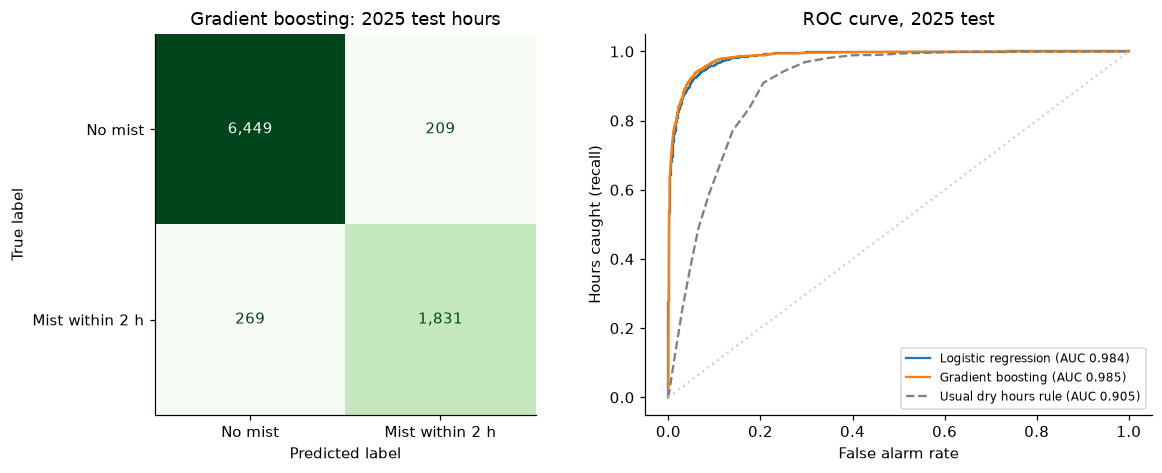

In [10]:
best = "Gradient boosting"
pred_best = (probs[best] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, pred_best).ravel()
print(f"{best}: caught {tp:,} of {tp + fn:,} misting-due hours in 2025, missed {fn:,}, false alarms {fp:,}")
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred_best), display_labels=["No mist", "Mist within 2 h"]).plot(ax=ax[0], cmap="Greens", colorbar=False, values_format=",")
ax[0].set_title(f"{best}: 2025 test hours")
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_te, p); ax[1].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te, p):.3f})")
fpr, tpr, _ = roc_curve(y_te, clim_prob); ax[1].plot(fpr, tpr, "--", color="grey", label=f"Usual dry hours rule (AUC {roc_auc_score(y_te, clim_prob):.3f})")
ax[1].plot([0, 1], [0, 1], ":", color="lightgrey"); ax[1].set_xlabel("False alarm rate"); ax[1].set_ylabel("Hours caught (recall)")
ax[1].set_title("ROC curve, 2025 test"); ax[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "confusion_and_roc.png", dpi=200, bbox_inches="tight")
fig.canvas.draw()
for i, name in enumerate(["confusion_matrix.png", "roc_curve.png"]):   # the two panels, saved separately
    ext = ax[i].get_tightbbox().transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(FIG / name, dpi=200, bbox_inches=ext.expanded(1.03, 1.03))
plt.show()

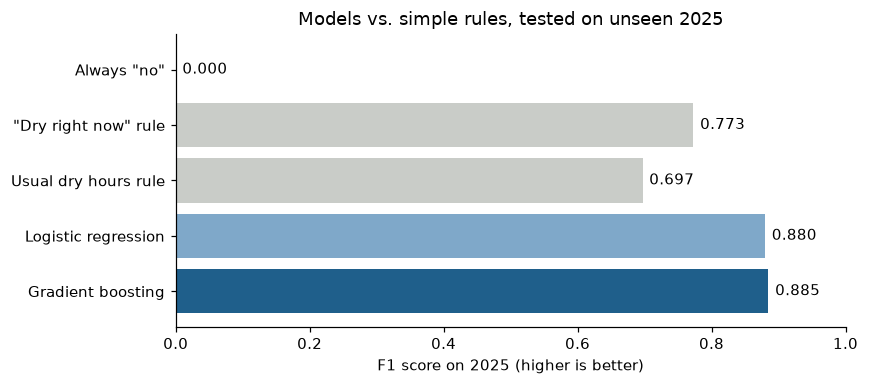

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.6))
order = ['Always "no"', '"Dry right now" rule', "Usual dry hours rule", "Logistic regression", "Gradient boosting"]
colors = ["#C9CCC8", "#C9CCC8", "#C9CCC8", "#7FA8C9", "#1F5F8B"]
vals = table.loc[order, "F1"]
ax.barh(order, vals, color=colors)
for i, v in enumerate(vals): ax.text(v + 0.01, i, f"{v:.3f}", va="center")
ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("F1 score on 2025 (higher is better)")
ax.set_title("Models vs. simple rules, tested on unseen 2025")
plt.tight_layout(); plt.savefig(FIG / "f1_models_vs_baselines.png", dpi=200, bbox_inches="tight"); plt.show()

## 9. Which features matter most? (top 5)

We use **permutation importance** on the 2025 test set:
1. Shuffle one feature so it becomes random noise.
2. Measure how much the model's F1 score drops.
3. A big drop means the model relies on that feature.

vapour_pressure_deficit    0.287
hour_cos                   0.034
soil_moisture_0_to_7cm     0.026
sun_change_1h              0.022
relative_humidity_2m       0.020
dtype: float64


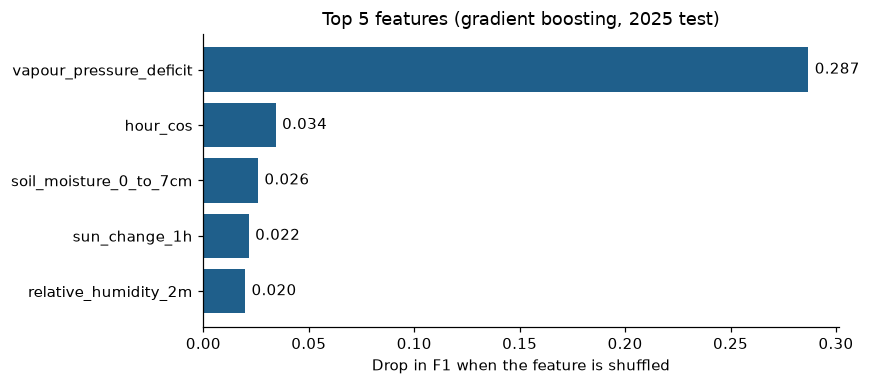

In [12]:
pi = permutation_importance(models[best], X_te, y_te, scoring="f1", n_repeats=5, random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)
top5 = imp.head(5)
print(top5.round(3))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(top5.index[::-1], top5.values[::-1], color="#1F5F8B")
for i, v in enumerate(top5.values[::-1]): ax.text(v + 0.003, i, f"{v:.3f}", va="center")
ax.set_xlabel("Drop in F1 when the feature is shuffled"); ax.set_title("Top 5 features (gradient boosting, 2025 test)")
plt.tight_layout(); plt.savefig(FIG / "top5_features.png", dpi=200, bbox_inches="tight"); plt.show()

### Three features explained

**1. VPD right now (`vapour_pressure_deficit`), the strongest feature.**
- Dry air rarely turns humid within an hour. The model's best clue about the next two hours is how dry the air is now.
- VPD is the measure plants actually respond to. Rising VPD increases the atmosphere's demand for water from leaves and pushes plants toward water stress (Grossiord et al., 2020).
- That's why the rig controls on VPD, not on humidity.

**2. Time of day (`hour_cos`): the sun.**
- In Penang, dry-stress hours are concentrated in the late morning and afternoon, when solar heating is highest.
- Incoming radiation is the main energy source that drives evaporation and warms the air (Allen et al., 1998, FAO-56).
- The hour tells the model where it is in that daily cycle. For example, 09:00 with rising VPD means "the afternoon is coming".

**3. Soil moisture (`soil_moisture_0_to_7cm`): the ground's water supply.**
- Wet ground evaporates water into the air. That keeps humidity up and VPD down.
- When the topsoil dries out, less energy goes into evaporation and more into heating the air, so VPD can climb faster (Seneviratne et al., 2010).
- For a grower, this is a useful early sign that a dry spell is building.

## 10. The driest day of 2025, replayed hour by hour

The model never saw 2025. Here is its probability of "misting needed within 2 h" on the day with the highest VPD, next to the actual VPD.

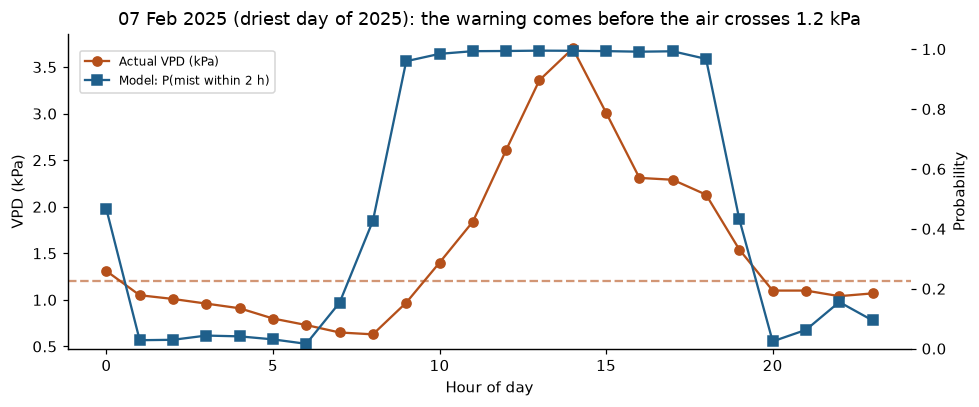

In [13]:
test_view = test.assign(prob=probs[best])
day = test_view.loc[test_view["vapour_pressure_deficit"].idxmax(), "time"].normalize()
one = test_view[test_view["time"].dt.normalize() == day]
fig, ax1 = plt.subplots(figsize=(9, 3.8))
ax1.plot(one["time"].dt.hour, one["vapour_pressure_deficit"], color="#B5501A", marker="o", label="Actual VPD (kPa)")
ax1.axhline(MIST_KPA, ls="--", color="#B5501A", alpha=.6); ax1.set_ylabel("VPD (kPa)"); ax1.set_xlabel("Hour of day")
ax2 = ax1.twinx(); ax2.plot(one["time"].dt.hour, one["prob"], color="#1F5F8B", marker="s", label="Model: P(mist within 2 h)")
ax2.set_ylim(0, 1.05); ax2.set_ylabel("Probability"); ax2.spines["top"].set_visible(False)
ax1.set_title(f"{day:%d %b %Y} (driest day of 2025): the warning comes before the air crosses 1.2 kPa")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88), fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "driest_day_replay.png", dpi=200, bbox_inches="tight"); plt.show()

## 11. Try it: predict any hour of 2025

This is the live-demo cell. Pick any hour of 2025, which the model never saw. It prints:
- that hour's weather
- the model's prediction
- what actually happened in the next two hours

Change the dates and run the cell again.

In [14]:
def predict_hour(when):
    row = test[test["time"] == pd.Timestamp(when)]
    p = models[best].predict_proba(row[FEATURES])[0, 1]
    r = row.iloc[0]
    print(f"{when}:  {r.temperature_2m:.1f} °C, RH {r.relative_humidity_2m:.0f} %, VPD now {r.vapour_pressure_deficit:.2f} kPa, "
          f"sun {r.shortwave_radiation:.0f} W/m²  ->  P(mist within 2 h) = {p:.2f}  "
          f"[{'WARN: mist soon' if p >= 0.5 else 'no warning'}]   actually needed: {'yes' if r.mist_next_2h else 'no'}")

for when in ["2025-02-07 07:00", "2025-02-07 08:00", "2025-02-07 09:00", "2025-11-24 13:00", "2025-06-15 12:00"]:
    predict_hour(when)

2025-02-07 07:00:  23.2 °C, RH 77 %, VPD now 0.65 kPa, sun 0 W/m²  ->  P(mist within 2 h) = 0.15  [no warning]   actually needed: no
2025-02-07 08:00:  23.2 °C, RH 78 %, VPD now 0.63 kPa, sun 7 W/m²  ->  P(mist within 2 h) = 0.43  [no warning]   actually needed: yes
2025-02-07 09:00:  25.0 °C, RH 69 %, VPD now 0.97 kPa, sun 139 W/m²  ->  P(mist within 2 h) = 0.96  [WARN: mist soon]   actually needed: yes
2025-11-24 13:00:  26.0 °C, RH 87 %, VPD now 0.42 kPa, sun 393 W/m²  ->  P(mist within 2 h) = 0.00  [no warning]   actually needed: no
2025-06-15 12:00:  31.5 °C, RH 62 %, VPD now 1.74 kPa, sun 687 W/m²  ->  P(mist within 2 h) = 0.98  [WARN: mist soon]   actually needed: yes


## 12. Save the trained model

In [15]:
joblib.dump({"model": models[best], "features": FEATURES, "threshold": 0.5, "mist_kpa": MIST_KPA}, "models/semai_forecast_gb.joblib")
table.to_csv(FIG / "results_table.csv")
top5.to_csv(FIG / "top5_features.csv", header=["f1_drop"])
print("Saved models/semai_forecast_gb.joblib")

Saved models/semai_forecast_gb.joblib


### Poster figures

These are the same results, re-drawn with bigger text so they're readable on the A2 poster.

In [16]:
with plt.rc_context({"font.size": 17, "axes.titlesize": 18, "axes.labelsize": 17, "legend.fontsize": 14}):
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred_best), display_labels=["No mist", "Mist in 2 h"]).plot(ax=ax, cmap="Greens", colorbar=False, values_format=",")
    ax.set_title("Gradient boosting, 2025"); plt.tight_layout(); plt.savefig(FIG / "poster_confusion.png", dpi=220); plt.close()

    fig, ax = plt.subplots(figsize=(8, 5.6))
    for name, p, c in [("Gradient boosting", probs["Gradient boosting"], "#1F5F8B"), ("Logistic regression", probs["Logistic regression"], "#7FA8C9")]:
        fpr, tpr, _ = roc_curve(y_te, p); ax.plot(fpr, tpr, lw=3, color=c, label=f"{name} (AUC {roc_auc_score(y_te, p):.3f})")
    fpr, tpr, _ = roc_curve(y_te, clim_prob); ax.plot(fpr, tpr, "--", lw=2.5, color="grey", label=f"Usual dry hours rule (AUC {roc_auc_score(y_te, clim_prob):.3f})")
    ax.plot([0, 1], [0, 1], ":", color="lightgrey"); ax.set_xlabel("False alarm rate"); ax.set_ylabel("Hours caught (recall)")
    ax.set_title("ROC curve, unseen 2025"); ax.legend(loc="lower right"); plt.tight_layout(); plt.savefig(FIG / "poster_roc.png", dpi=220); plt.close()

    fig, ax1 = plt.subplots(figsize=(8, 4.6))
    ax1.plot(one["time"].dt.hour, one["vapour_pressure_deficit"], color="#B5501A", marker="o", lw=2.5, label="Actual VPD (kPa)")
    ax1.axhline(MIST_KPA, ls="--", color="#B5501A", alpha=.6); ax1.set_ylabel("VPD (kPa)"); ax1.set_xlabel("Hour of day")
    ax2 = ax1.twinx(); ax2.plot(one["time"].dt.hour, one["prob"], color="#1F5F8B", marker="s", lw=2.5, label="P(mist within 2 h)")
    ax2.set_ylim(0, 1.05); ax2.set_ylabel("Model probability"); ax2.spines["top"].set_visible(False)
    ax1.set_title(f"{day:%d %b %Y}, driest day of 2025"); fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.86))
    plt.tight_layout(); plt.savefig(FIG / "poster_driest_day.png", dpi=220); plt.close()
print("Poster figures saved in", FIG)

Poster figures saved in figures


## 13. Conclusions and limits

- **See the summary table in section 7:** gradient boosting beats every simple rule on unseen 2025, on F1, recall and ROC AUC.
- **The top features make physical sense.** The current VPD, the sun and the time of day decide whether the next two hours turn dry.
- **Limits:**
  - This is outdoor ERA5 reanalysis data, a gridded estimate, not a weather station or the inside of our greenhouse.
  - The next step is to retrain on the rig's own logged readings.

## References

- Allen, R. G., Pereira, L. S., Raes, D., & Smith, M. (1998). *Crop evapotranspiration: Guidelines for computing crop water requirements* (FAO Irrigation and Drainage Paper 56). FAO, Rome.
- Grossiord, C., Buckley, T. N., Cernusak, L. A., et al. (2020). Plant responses to rising vapor pressure deficit. *New Phytologist*, 226(6), 1550–1566.
- Hersbach, H., Bell, B., Berrisford, P., et al. (2020). The ERA5 global reanalysis. *Quarterly Journal of the Royal Meteorological Society*, 146(730), 1999–2049.
- Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Seneviratne, S. I., Corti, T., Davin, E. L., et al. (2010). Investigating soil moisture–climate interactions in a changing climate: A review. *Earth-Science Reviews*, 99(3–4), 125–161.
- Shamshiri, R. R., Jones, J. W., Thorp, K. R., et al. (2018). Review of optimum temperature, humidity, and vapour pressure deficit for microclimate evaluation and control in greenhouse cultivation of tomato: a review. *International Agrophysics*, 32(2), 287–302.
- Zippenfenig, P. (2023). *Open-Meteo.com Weather API* [Computer software]. Zenodo. https://doi.org/10.5281/zenodo.7970649 (data licence CC BY 4.0)